# 2.3 可解释性示例
本 Notebook 基于 **PyTorch Geometric (PyG)**，演示可解释性方法在分子性质预测中的应用（以ESOL任务为例）：
- **Integrated Gradients (IG)**
- **Substructure-Mask Explanation (SME)**

### （1）训练GIN模型

In [2]:
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool
from torch.utils.data import random_split
import torch_geometric.transforms as T
from torch_geometric.data import Data
from torch_geometric.datasets import MoleculeNet
from rdkit import Chem
import copy
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import SimilarityMaps
from IPython.display import SVG, display
from torch_geometric.utils.smiles import from_smiles
from rdkit.Chem.Draw import rdMolDraw2D
import os
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader


# =========================================================
# 0. 运行前提
# =========================================================
# 你需要在前面已经准备好：
# - ds_cls : 分类数据集（如 BBBP）
# - ds_reg : 回归数据集（如 ESOL）
# - device : 运行设备，例如：
#   device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# 1. 固定随机种子
# =========================================================
def set_global_seed(seed=42, deterministic=True):
    """固定随机种子，尽量保证结果可复现"""
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass


# =========================================================
# 2. 数据集划分
# =========================================================
def split_dataset(dataset, train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    将数据集划分为 train / val / test
    默认比例：8 : 1 : 1
    """
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=generator
    )
    return train_set, val_set, test_set


# =========================================================
# 3. 超参数配置
# =========================================================
REG_HP = {
    "task": "reg",
    "seed": 42,
    "batch_size_train": 64,
    "batch_size_eval": 256,
    "hidden_dim": 128,
    "num_layers": 4,
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 100,
    "model_dir": "saved_models",
    "task_name": "gin_reg"
}


# =========================================================
# 4. 模型定义
# =========================================================
class MLP(nn.Module):
    """两层感知机，用作分类头或回归头"""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class GINBackbone(nn.Module):
    """GIN 主干：输入图，输出图级表示"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, batch)
        return g

class GINRegressor(nn.Module):
    """GIN 回归模型，输出 1 个连续值"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)
        self.head = MLP(hidden_dim, hidden_dim, 1, dropout)

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)
        return self.head(g).view(-1)


def build_model(task, dataset, hp, device):
    """根据任务类型构建模型"""
    if task == "cls":
        return GINClassifier(
            in_dim=dataset.num_features,
            hidden_dim=hp["hidden_dim"],
            num_layers=hp["num_layers"],
            dropout=hp["dropout"]
        ).to(device)

    if task == "reg":
        return GINRegressor(
            in_dim=dataset.num_features,
            hidden_dim=hp["hidden_dim"],
            num_layers=hp["num_layers"],
            dropout=hp["dropout"]
        ).to(device)

    raise ValueError(f"未知任务类型：{task}")


# =========================================================
# 5. 训练与评估函数
# =========================================================
def train_one_epoch_regression(model, loader, optimizer, device):
    """回归任务训练一个 epoch，返回平均 MSE 损失"""
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        pred = model(batch)
        y = batch.y.view(-1).float()
        loss = F.mse_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item() * y.size(0)

    return total_loss / max(len(loader.dataset), 1)

@torch.no_grad()
def eval_regression(model, loader, device):
    """回归评估：返回 (mae, rmse)"""
    model.eval()
    ys, ps = [], []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        y = batch.y.view(-1).float()

        ys.append(y.detach().cpu())
        ps.append(pred.detach().cpu())

    y = torch.cat(ys)
    p = torch.cat(ps)

    mae = torch.mean(torch.abs(p - y)).item()
    rmse = torch.sqrt(torch.mean((p - y) ** 2)).item()
    return mae, rmse


# =========================================================
# 6. 保存与加载
# =========================================================
def make_model_name(task_name, hp):
    """根据超参数生成模型文件名"""
    return (
        f"{task_name}"
        f"_seed{hp['seed']}"
        f"_bs{hp['batch_size_train']}"
        f"_hd{hp['hidden_dim']}"
        f"_L{hp['num_layers']}"
        f"_do{hp['dropout']}"
        f"_lr{hp['lr']}"
        f"_wd{hp['weight_decay']}"
        f"_ep{hp['epochs']}"
        f".pt"
    )


def load_trained_model(task, dataset, hp, device):
    """加载已保存模型"""
    if task == "cls":
        task_name = "gin_cls"
    elif task == "reg":
        task_name = "gin_reg"
    else:
        raise ValueError(f"未知任务类型：{task}")

    save_name = make_model_name(task_name, hp)
    save_path = os.path.join(hp["model_dir"], save_name)

    if not os.path.exists(save_path):
        raise FileNotFoundError(f"找不到模型文件：{save_path}")

    model = build_model(task, dataset, hp, device)
    ckpt = torch.load(save_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"成功加载模型：{save_path}")
    return model, ckpt

# =========================================================
# 7. 回归训练主函数
# =========================================================
def train_regressor(dataset, hp, device):
    """
    回归训练主函数
    模型选择标准：验证集 RMSE 最小
    """
    set_global_seed(hp["seed"])

    train_set, val_set, test_set = split_dataset(dataset, seed=hp["seed"])

    train_loader = DataLoader(
        train_set,
        batch_size=hp["batch_size_train"],
        shuffle=True
    )
    val_loader = DataLoader(
        val_set,
        batch_size=hp["batch_size_eval"],
        shuffle=False
    )
    test_loader = DataLoader(
        test_set,
        batch_size=hp["batch_size_eval"],
        shuffle=False
    )

    model = build_model("reg", dataset, hp, device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"]
    )

    best_val_rmse = float("inf")
    best_state = None

    print("\n开始训练回归模型...")

    for epoch in range(1, hp["epochs"] + 1):
        train_loss = train_one_epoch_regression(model, train_loader, optimizer, device)
        val_mae, val_rmse = eval_regression(model, val_loader, device)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"第 {epoch:03d} 轮 | "
                f"训练损失 = {train_loss:.4f} | "
                f"验证集 MAE = {val_mae:.4f} | "
                f"验证集 RMSE = {val_rmse:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_mae, test_rmse = eval_regression(model, test_loader, device)

    Path(hp["model_dir"]).mkdir(parents=True, exist_ok=True)
    save_name = make_model_name(hp["task_name"], hp)
    save_path = os.path.join(hp["model_dir"], save_name)

    torch.save({
        "task": "reg",
        "model_state_dict": model.state_dict(),
        "hyperparameters": dict(hp),
        "best_val_rmse": best_val_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse
    }, save_path)

    print(f"\n回归模型训练完成")
    print(f"最佳验证集 RMSE = {best_val_rmse:.4f}")
    print(f"测试集 MAE     = {test_mae:.4f}")
    print(f"测试集 RMSE    = {test_rmse:.4f}")
    print(f"模型已保存到：{save_path}")

    return model, save_path


# =========================================================
# 8. 调用示例
# =========================================================
def load_esol(root="./data"):
    ds = MoleculeNet(root=root, name="ESOL")
    return ds, "ESOL"

# 载入数据
ds_reg, reg_name = load_esol("./data")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed_everything(42)
device = get_device()
    
# 训练模型
model_reg, reg_save_path = train_regressor(ds_reg, REG_HP, device)


开始训练回归模型...
第 001 轮 | 训练损失 = 8.6798 | 验证集 MAE = 1.6886 | 验证集 RMSE = 2.2202
第 010 轮 | 训练损失 = 1.3048 | 验证集 MAE = 1.1773 | 验证集 RMSE = 1.6405
第 020 轮 | 训练损失 = 1.0854 | 验证集 MAE = 1.0389 | 验证集 RMSE = 1.3597
第 030 轮 | 训练损失 = 1.0298 | 验证集 MAE = 0.9065 | 验证集 RMSE = 1.1774
第 040 轮 | 训练损失 = 0.9985 | 验证集 MAE = 0.9824 | 验证集 RMSE = 1.3094
第 050 轮 | 训练损失 = 0.8493 | 验证集 MAE = 0.9336 | 验证集 RMSE = 1.1949
第 060 轮 | 训练损失 = 0.6628 | 验证集 MAE = 0.8827 | 验证集 RMSE = 1.2107
第 070 轮 | 训练损失 = 0.7996 | 验证集 MAE = 1.3792 | 验证集 RMSE = 1.8014
第 080 轮 | 训练损失 = 0.6422 | 验证集 MAE = 0.7530 | 验证集 RMSE = 0.9908
第 090 轮 | 训练损失 = 0.7686 | 验证集 MAE = 0.7945 | 验证集 RMSE = 1.0868
第 100 轮 | 训练损失 = 0.6526 | 验证集 MAE = 0.6074 | 验证集 RMSE = 0.7838

回归模型训练完成
最佳验证集 RMSE = 0.7838
测试集 MAE     = 0.5561
测试集 RMSE    = 0.7605
模型已保存到：saved_models\gin_reg_seed42_bs64_hd128_L4_do0.2_lr0.001_wd1e-05_ep100.pt


### （2）Integrated Gradients (IG)应用于ESOL任务

成功加载模型：saved_models\gin_reg_seed42_bs64_hd128_L4_do0.2_lr0.001_wd1e-05_ep100.pt
===== ESOL 回归结果 =====
SMILES： OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
预测值（eval）：-1.303994
MC-Dropout 均值：-1.317219
不确定度（MC 方差）：0.010003
真实 ESOL 数值：-0.770000
预测绝对误差：0.533994
MC 均值绝对误差：0.547219
IG 积分步数：64
MC-Dropout 采样次数：50


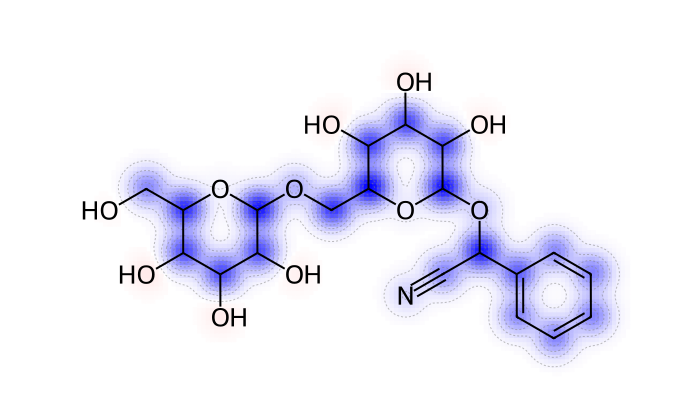

[ESOL|dataset item] IG 原子热图 | 预测 = -1.303994 | MC均值 = -1.317219 | 不确定度 = 0.010003
===== ESOL 回归结果 =====
SMILES： CCOCCc1cc(CC(=O)O)ccc1CO
预测值（eval）：-2.283225
MC-Dropout 均值：-2.280576
不确定度（MC 方差）：0.020965
IG 积分步数：64
MC-Dropout 采样次数：50


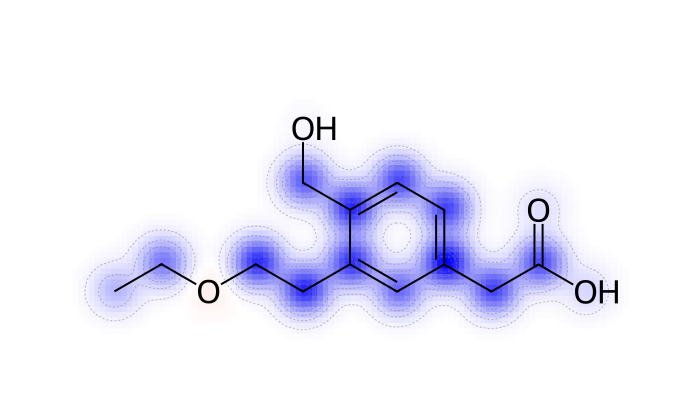

[ESOL|SMILES] IG 原子热图 | 预测 = -2.283225 | MC均值 = -2.280576 | 不确定度 = 0.020965


In [3]:
rdDepictor.SetPreferCoordGen(True)


# =========================================================
# 0. 模型载入：与前文一致
# 需要你前文已经定义：
#   load_trained_model(task, dataset, cfg, device)
# =========================================================
def load_explainer_model_reg(dataset, cfg, device):
    cfg_local = copy.deepcopy(cfg)
    cfg_local["task"] = "reg"
    model, ckpt = load_trained_model("reg", dataset, cfg_local, device)
    model.eval()
    return model, ckpt


# =========================================================
# 1. 通用工具
# =========================================================
def _extract_main_output(out):
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out


def _copy_data(data, new_x=None):
    new_data = Data()
    for k, v in data:
        new_data[k] = v
    if new_x is not None:
        new_data.x = new_x
    return new_data


def _ensure_batch(data):
    if (not hasattr(data, "batch")) or (data.batch is None):
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long)
    return data


def _enable_dropout_only(model):
    """
    保持整体 eval，只把 Dropout 层切到 train。
    这样不会把 BatchNorm 一起切到训练态。
    """
    model.eval()
    dropout_types = (
        nn.Dropout,
        nn.Dropout1d,
        nn.Dropout2d,
        nn.Dropout3d,
        nn.AlphaDropout,
        nn.FeatureAlphaDropout,
    )
    for m in model.modules():
        if isinstance(m, dropout_types):
            m.train()


# =========================================================
# 2. SMILES -> PyG Data
# 仅适用于：训练时本来就使用了 PyG 的 from_smiles / 同构图方式
# 如果你的训练集不是这样构建的，就不要用它做“对照旧结果”
# =========================================================
def smiles_to_data_pyg(smiles, ref_dataset=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit 解析 SMILES 失败：{smiles}")

    data = from_smiles(smiles)
    data.smiles = smiles
    data = _ensure_batch(data)

    if ref_dataset is not None:
        ref = ref_dataset[0]

        if hasattr(ref, "x") and ref.x is not None:
            if data.x.size(-1) != ref.x.size(-1):
                raise ValueError(
                    f"x 维度不一致：当前分子 x_dim={data.x.size(-1)}，"
                    f"训练数据 x_dim={ref.x.size(-1)}"
                )
            if data.x.dtype != ref.x.dtype:
                data.x = data.x.to(ref.x.dtype)

        ref_has_edge_attr = hasattr(ref, "edge_attr") and ref.edge_attr is not None
        cur_has_edge_attr = hasattr(data, "edge_attr") and data.edge_attr is not None

        if ref_has_edge_attr != cur_has_edge_attr:
            raise ValueError("当前分子与训练数据在 edge_attr 是否存在这一点上不一致。")

        if ref_has_edge_attr and cur_has_edge_attr:
            if data.edge_attr.size(-1) != ref.edge_attr.size(-1):
                raise ValueError(
                    f"edge_attr 维度不一致：当前分子 edge_attr_dim={data.edge_attr.size(-1)}，"
                    f"训练数据 edge_attr_dim={ref.edge_attr.size(-1)}"
                )
            if data.edge_attr.dtype != ref.edge_attr.dtype:
                data.edge_attr = data.edge_attr.to(ref.edge_attr.dtype)

    return data


# =========================================================
# 3. 回归预测
# =========================================================
@torch.no_grad()
def predict_regression_deterministic(model, data):
    model.eval()
    out = model(data)
    out = _extract_main_output(out)
    return out.view(-1)


# =========================================================
# 4. MC-Dropout：回归预测与不确定度
# 注意：这里只打开 dropout，不打开整个 train()
# =========================================================
@torch.no_grad()
def mc_dropout_predict_regression(model, data, T=50):
    _enable_dropout_only(model)

    preds = []
    for _ in range(T):
        out = model(data)
        out = _extract_main_output(out)
        preds.append(out.view(-1).unsqueeze(0))

    preds = torch.cat(preds, dim=0)   # [T, B]
    mean_pred = preds.mean(dim=0)
    var_pred = preds.var(dim=0, unbiased=False)

    # 采样完成后恢复 eval
    model.eval()
    return mean_pred, var_pred


# =========================================================
# 5. IG：对节点特征 x 计算积分梯度
# =========================================================
def integrated_gradients_x_regression(model, data, steps=64, baseline=None):
    """
    对节点输入特征 x 做 Integrated Gradients。
    这里允许原始 x 不是 float，会先转成 float 后再做 IG。
    最终得到 attr: [N, F]，可在特征维上聚合为原子级重要性。
    """
    model.eval()
    device = next(model.parameters()).device
    data = _copy_data(data).to(device)

    # 直接转成 float，继续做 IG
    x0 = data.x.detach().float()

    if baseline is None:
        baseline = torch.zeros_like(x0)
    else:
        baseline = baseline.to(device).float()

    total_grad = torch.zeros_like(x0)

    for i in range(1, steps + 1):
        alpha = float(i) / steps
        xi = (baseline + alpha * (x0 - baseline)).detach()
        xi.requires_grad_(True)

        d_i = _copy_data(data, new_x=xi).to(device)
        out = model(d_i)
        out = _extract_main_output(out)
        score = out.view(-1)[0]

        model.zero_grad(set_to_none=True)
        if xi.grad is not None:
            xi.grad.zero_()

        score.backward()
        total_grad += xi.grad.detach()

    avg_grad = total_grad / steps
    attr = (x0 - baseline) * avg_grad
    return attr.detach()


# =========================================================
# 6. RDKit 热图显示
# =========================================================
def show_attribution_map(mol, weights_signed, title="", cmap_name="bwr"):
    w = np.asarray(weights_signed, dtype=float).reshape(-1)
    w = [float(x) for x in w.tolist()]

    d2d = Draw.MolDraw2DSVG(700, 420)
    d2d.drawOptions().useBWAtomPalette()

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        w,
        d2d,
        colorMap=cmap_name,
        alpha=0
    )

    d2d.FinishDrawing()
    display(SVG(d2d.GetDrawingText()))

    if title:
        print(title)


# =========================================================
# 7. 单个 Data 图的解释
# 这是最稳妥的入口：直接吃已经构建好的 PyG Data
# =========================================================
def explain_one_data_esol(
    data,
    model,
    device,
    true_value=None,
    T=50,
    steps=64,
    baseline=None,
    title_prefix="[ESOL]",
):
    data = _copy_data(data)
    data = _ensure_batch(data).to(device)

    # ---- 预测 ----
    det_pred = predict_regression_deterministic(model, data)
    pred_value = float(det_pred.view(-1)[0].item())

    # ---- MC-Dropout ----
    mc_mean, mc_var = mc_dropout_predict_regression(model, data, T=T)
    mc_mean_value = float(mc_mean.view(-1)[0].item())
    uncertainty = float(mc_var.view(-1)[0].item())

    # ---- IG ----
    attr_x = None
    node_signed = None
    node_abs = None
    ig_error = None

    try:
        attr_x = integrated_gradients_x_regression(
            model=model,
            data=data,
            steps=steps,
            baseline=baseline
        )
        node_signed = attr_x.sum(dim=1).detach().cpu().numpy()
        node_abs = attr_x.abs().sum(dim=1).detach().cpu().numpy()
    except Exception as e:
        ig_error = str(e)

    # ---- 展示 ----
    smiles = getattr(data, "smiles", None)

    print("===== ESOL 回归结果 =====")
    if smiles is not None:
        print("SMILES：", smiles)
    print(f"预测值（eval）：{pred_value:.6f}")
    print(f"MC-Dropout 均值：{mc_mean_value:.6f}")
    print(f"不确定度（MC 方差）：{uncertainty:.6f}")

    if true_value is not None:
        print(f"真实 ESOL 数值：{true_value:.6f}")
        print(f"预测绝对误差：{abs(pred_value - true_value):.6f}")
        print(f"MC 均值绝对误差：{abs(mc_mean_value - true_value):.6f}")

    print(f"IG 积分步数：{steps}")
    print(f"MC-Dropout 采样次数：{T}")

    if ig_error is not None:
        print("IG 未执行：", ig_error)

    # ---- 画图 ----
    if (smiles is not None) and (node_signed is not None):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None and mol.GetNumAtoms() == len(node_signed):
            show_attribution_map(
                mol,
                node_signed,
                title=(
                    f"{title_prefix} IG 原子热图 | "
                    f"预测 = {pred_value:.6f} | "
                    f"MC均值 = {mc_mean_value:.6f} | "
                    f"不确定度 = {uncertainty:.6f}"
                )
            )
        else:
            print("未绘制热图：RDKit 分子与归因长度不一致。")

    return {
        "smiles": smiles,
        "pred_value": pred_value,          #  eval 预测
        "mc_mean_value": mc_mean_value,    # MC-Dropout 均值
        "true_value": true_value,
        "uncertainty": uncertainty,
        "node_signed": node_signed,
        "node_abs": node_abs,
        "attr_x": None if attr_x is None else attr_x.detach().cpu().numpy(),
        "ig_error": ig_error,
    }


# =========================================================
# 8. 从数据集中取一个样本进行展示
# 关键修正：
# 直接使用 dataset[index] 原图，不再从 smiles 重建
# =========================================================
def explain_dataset_item_esol(
    dataset,
    index,
    cfg,
    device,
    T=50,
    steps=64,
    baseline=None,
    model=None,
):
    if model is None:
        model, ckpt = load_explainer_model_reg(dataset, cfg, device)

    item = dataset[index]

    true_value = None
    if hasattr(item, "y") and item.y is not None:
        true_value = float(item.y.view(-1)[0].item())

    return explain_one_data_esol(
        data=item,
        model=model,
        device=device,
        true_value=true_value,
        T=T,
        steps=steps,
        baseline=baseline,
        title_prefix="[ESOL|dataset item]",
    )


# =========================================================
# 9. 给定一个外部分子 SMILES 进行展示
# 注意：
# 只有当你的训练数据本来也是用同样的 PyG from_smiles 方式构图时，
# 这个函数得到的结果才有可比性。
# =========================================================
def explain_one_molecule_esol(
    smiles,
    ref_dataset,
    cfg,
    device,
    true_value=None,
    T=50,
    steps=64,
    baseline=None,
    model=None,
):
    if model is None:
        model, ckpt = load_explainer_model_reg(ref_dataset, cfg, device)

    data = smiles_to_data_pyg(smiles, ref_dataset=ref_dataset)

    return explain_one_data_esol(
        data=data,
        model=model,
        device=device,
        true_value=true_value,
        T=T,
        steps=steps,
        baseline=baseline,
        title_prefix="[ESOL|SMILES]",
    )


# =========================================================
# 10. 使用示例
# =========================================================
UQ_CFG = {
    "task": "reg",                
    "seed": 42,
    "batch_size_train": 64,
    "batch_size_eval": 64,
    "hidden_dim": 128,
    "num_layers": 4,
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 100,
    "model_dir": "saved_models",
    "mc_T": 100,
    "eval_split": "test"
}

# ---------- 先统一载入一次模型 ----------
model_reg_loaded, reg_ckpt = load_explainer_model_reg(ds_reg, UQ_CFG, device)

# ---------- 示例1：解释数据集中的某个样本 ----------
result_dataset = explain_dataset_item_esol(
    dataset=ds_reg,
    index=0,
    cfg=UQ_CFG,
    device=device,
    T=50,
    steps=64,
    baseline=None,
    model=model_reg_loaded,
)

print("=========================================================")

# ---------- 示例2：解释一个外部 SMILES ----------
# 仅在训练集本来也是用同样 PyG 构图方式时再用它
result_smiles = explain_one_molecule_esol(
    smiles="CCOCCc1cc(CC(=O)O)ccc1CO",
    ref_dataset=ds_reg,
    cfg=UQ_CFG,
    device=device,
    true_value=None,
    T=50,
    steps=64,
    baseline=None,
    model=model_reg_loaded,
)

### （3）Substructure Mask Explanation (SME)应用于ESOL任务

### 1. 先重新训练可支持mask掩盖的GIN模型。

In [5]:
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool, global_add_pool



# =========================
# 0. 支持MASK掩盖的GIN 
# =========================
class GINMaskRegressor(nn.Module):
    """支持 pooling-mask 的回归模型：拆分为节点编码和图读出两步"""
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.x_proj = nn.Linear(in_dim, hidden_dim)  # 输入特征先映射到 hidden_dim

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp, train_eps=True))  # train_eps=True：epsilon 参数可学习
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),   # 回归输出
        )

    def encode_nodes(self, data):
        """节点编码阶段：输出每个节点的 embedding"""
        x = data.x.float()
        h = self.x_proj(x)

        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, data.edge_index)               # 节点消息传递
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        return h                                      # [N, hidden_dim]

    def readout(self, h, batch, node_keep_mask=None):
        """图读出阶段：支持在 pooling 时屏蔽部分节点"""
        if node_keep_mask is not None:
            h = h * node_keep_mask.view(-1, 1).to(h.dtype)  # 被屏蔽节点贡献置零

        g = global_add_pool(h, batch)                 # 节点表示求和为图表示
        out = self.head(g).view(-1)                   # 图级回归输出
        return out

    def forward(self, data, node_keep_mask=None):
        if not hasattr(data, "batch") or data.batch is None:
            data.batch = torch.zeros(
                data.num_nodes,
                dtype=torch.long,
                device=data.x.device
            )                                         # 单图时手动补 batch

        h = self.encode_nodes(data)                   # 节点编码
        out = self.readout(h, data.batch, node_keep_mask=node_keep_mask)  # 图读出
        return out




# =========================
# 1. 数据集划分与加载
# =========================
ds_reg = MoleculeNet(root="./data", name="ESOL")                  # ESOL：水溶解度回归数据集

train_set, val_set, test_set = split_dataset(ds_reg, seed=42)    # 按固定随机种子划分 train / val / test

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)  # 训练集：小批量加载并打乱
val_loader   = DataLoader(val_set, batch_size=256)                 # 验证集：只做前向评估
test_loader  = DataLoader(test_set, batch_size=256)                # 测试集：只做最终评估


# =========================
# 2. 模型构建
# =========================
model_reg = GINMaskRegressor(                                     # 构建支持 pooling-mask 的 GIN 回归模型
    in_dim=ds_reg.num_features,                                   # 节点输入特征维度
    hidden_dim=64,                                                # 隐藏层维度
    num_layers=3,                                                 # GINConv 层数
    dropout=0.2                                                   # dropout 概率
).to(device)


# =========================
# 3. 优化器设置
# =========================
opt = torch.optim.Adam(
    model_reg.parameters(),                                       # 优化模型全部参数
    lr=1e-3,                                                      # 学习率
    weight_decay=1e-5                                             # L2 正则
)


# =========================
# 4. 训练过程
# =========================
best_val, best_state = 1e9, None                                  # 记录最优验证集 RMSE 及对应参数

for epoch in range(1, 101):                                        # 训练 50 个 epoch
    loss = train_one_epoch_regression(                            # 训练一个 epoch，返回平均训练损失
        model_reg, train_loader, opt, device
    )
    val_rmse, val_mae = eval_regression(                          # 在验证集上评估 RMSE 和 MAE
        model_reg, val_loader, device
    )

    if val_rmse < best_val:                                       # 若当前验证 RMSE 更小，则保存参数
        best_val = val_rmse
        best_state = {
            k: v.detach().cpu() for k, v in model_reg.state_dict().items()
        }

    if epoch % 10 == 0:                                            # 每 5 轮打印一次训练信息
        print(
            f"第 {epoch:03d} 轮 | "
            f"训练损失 = {loss:.4f} | "
            f"验证集 MAE = {val_mae:.4f} | "
            f"验证集 RMSE = {val_rmse:.4f}"
        )


# =========================
# 5. 恢复最佳模型
# =========================
if best_state is not None:
    model_reg.load_state_dict(best_state)                         # 恢复验证集表现最好的模型参数


# =========================
# 6. 测试集评估
# =========================
test_rmse, test_mae = eval_regression(model_reg, test_loader, device)  # 在测试集上评估最终性能

print("最佳验证集 RMSE =", best_val)
print("测试集 RMSE     =", test_rmse)
print("测试集 MAE       =", test_mae)

第 010 轮 | 训练损失 = 1.5512 | 验证集 MAE = 1.1359 | 验证集 RMSE = 0.9076
第 020 轮 | 训练损失 = 1.1823 | 验证集 MAE = 1.1099 | 验证集 RMSE = 0.8251
第 030 轮 | 训练损失 = 1.0525 | 验证集 MAE = 0.9484 | 验证集 RMSE = 0.7079
第 040 轮 | 训练损失 = 0.8659 | 验证集 MAE = 0.8420 | 验证集 RMSE = 0.6493
第 050 轮 | 训练损失 = 0.8491 | 验证集 MAE = 0.8969 | 验证集 RMSE = 0.6884
第 060 轮 | 训练损失 = 0.9046 | 验证集 MAE = 1.5925 | 验证集 RMSE = 1.2358
第 070 轮 | 训练损失 = 0.8138 | 验证集 MAE = 0.9657 | 验证集 RMSE = 0.7540
第 080 轮 | 训练损失 = 0.7582 | 验证集 MAE = 0.8012 | 验证集 RMSE = 0.6178
第 090 轮 | 训练损失 = 0.7899 | 验证集 MAE = 0.9506 | 验证集 RMSE = 0.7410
第 100 轮 | 训练损失 = 0.8484 | 验证集 MAE = 1.7771 | 验证集 RMSE = 1.4058
最佳验证集 RMSE = 0.5627515912055969
测试集 RMSE     = 0.4631790220737457
测试集 MAE       = 0.6471026539802551


### 2. SME解释

SMILES: CCOCCc1cc(CC(=O)O)ccc1CO
预测结果: -1.9893

子结构与归因值:
01. 原子序号=[0, 1] | 子结构=CC | 归因值=-0.0449
02. 原子序号=[2] | 子结构=O | 归因值=0.0074
03. 原子序号=[3, 4] | 子结构=CC | 归因值=-0.2251
04. 原子序号=[5, 6, 7, 12, 13, 14] | 子结构=c1ccccc1 | 归因值=-1.4969
05. 原子序号=[8, 9, 10, 11] | 子结构=CC(=O)O | 归因值=0.1310
06. 原子序号=[15, 16] | 子结构=CO | 归因值=0.1050


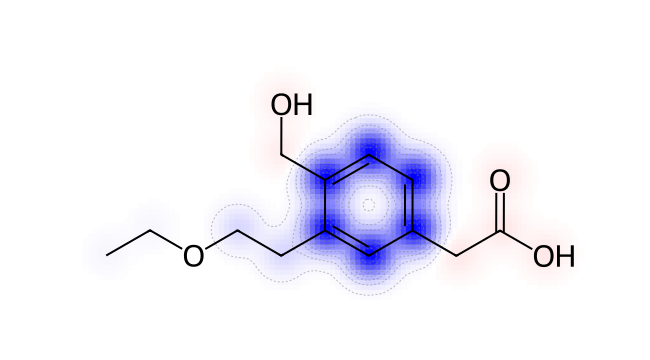

[REG | BRICS + pooling-mask]
SMILES: CCOCCc1cc(CC(=O)O)ccc1CO
预测值: -1.9893


In [6]:
import numpy as np
import torch
from torch_geometric.data import Data

from rdkit import Chem
from rdkit.Chem import BRICS
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw
from IPython.display import SVG, display

rdDepictor.SetPreferCoordGen(True)                         # 优先使用较美观的 2D 坐标生成方式


# =========================
# 1. 基础工具
# =========================
def smiles_to_data_pyg(smiles, ref_dataset=None):
    data = None

    try:
        from torch_geometric.utils.smiles import from_smiles
        data = from_smiles(smiles)                         # 优先用 PyG 自带的 SMILES -> Data
    except Exception:
        data = None

    if data is None:                                       # 若没有 from_smiles，则用 RDKit 兜底构图
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"RDKit 解析 SMILES 失败: {smiles}")

        x_list = []
        for a in mol.GetAtoms():
            x_list.append([
                a.GetAtomicNum(),                          # 原子序数
                a.GetTotalDegree(),                        # 原子度
                a.GetFormalCharge(),                       # 形式电荷
                a.GetTotalNumHs(),                         # 氢原子数
                float(a.GetIsAromatic()),                  # 是否芳香
                float(a.IsInRing()),                       # 是否在环中
            ])
        x = torch.tensor(x_list, dtype=torch.float)        # 节点特征矩阵 [N, F]

        row, col = [], []
        for b in mol.GetBonds():
            i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
            row += [i, j]
            col += [j, i]                                  # 无向边转为双向有向边

        edge_index = torch.tensor([row, col], dtype=torch.long)
        data = Data(x=x, edge_index=edge_index)

    if not torch.is_floating_point(data.x):
        data.x = data.x.float()                            # 保证节点特征是浮点类型

    data.smiles = smiles                                   # 保存原始 SMILES，便于后续可视化

    if not hasattr(data, "batch") or data.batch is None:
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long)  # 单图时补一个全 0 batch

    if ref_dataset is not None:
        ref_dim = ref_dataset[0].x.size(-1)
        cur_dim = data.x.size(-1)
        if cur_dim != ref_dim:                             # 检查当前分子的特征维度是否与训练集一致
            raise ValueError(
                f"当前 x 维度={cur_dim}，训练数据 x 维度={ref_dim}。\n"
                f"请使用与你构建 ds_reg 一致的 featurizer。"
            )

    return data


def data_to_mol(data):
    smi = data.smiles[0] if isinstance(data.smiles, (list, tuple)) else data.smiles  # 兼容 list / str
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        raise ValueError(f"RDKit 解析 SMILES 失败: {smi}")
    rdDepictor.Compute2DCoords(mol)                        # 生成 2D 坐标
    return mol, smi


def show_attribution_map(mol, weights, title="", cmap_name="bwr"):
    w = np.asarray(weights, dtype=float).reshape(-1)
    w = [float(x) for x in w.tolist()]                     # numpy -> Python list[float]

    d2d = Draw.MolDraw2DSVG(650, 360)
    d2d.drawOptions().useBWAtomPalette()                   # 原子用黑白配色，突出热图

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol, w, d2d,
        colorMap=cmap_name,                                # 常用 "bwr"：蓝-白-红
        alpha=0
    )
    d2d.FinishDrawing()
    display(SVG(d2d.GetDrawingText()))

    if title:
        print(title)


def normalize_signed_scores(scores, eps=1e-12):
    scores = np.asarray(scores, dtype=float)
    max_abs = np.max(np.abs(scores))
    if max_abs < eps:
        return np.zeros_like(scores)                       # 避免全 0 时除 0
    return scores / max_abs                                # 归一化到 [-1, 1]


# =========================
# 2. BRICS 拆分
# =========================
def brics_atom_fragments(mol):
    brics_bonds = list(BRICS.FindBRICSBonds(mol))          # 查找 BRICS 可切割键

    if len(brics_bonds) == 0:
        return [list(range(mol.GetNumAtoms()))]            # 若没有可切割键，则整个分子视作一个片段

    bond_indices = []
    for (a1, a2), _ in brics_bonds:
        bond = mol.GetBondBetweenAtoms(int(a1), int(a2))
        if bond is not None:
            bond_indices.append(bond.GetIdx())             # 收集需要切断的键索引

    if len(bond_indices) == 0:
        return [list(range(mol.GetNumAtoms()))]

    frag_mol = Chem.FragmentOnBonds(mol, bond_indices, addDummies=False)   # 按 BRICS 键切分
    frags = Chem.GetMolFrags(frag_mol, asMols=False, sanitizeFrags=False)  # 获取各片段原子索引

    return [list(frag) for frag in frags if len(frag) > 0]


def fragment_to_smiles(mol, atom_ids):
    atom_ids = sorted(set(int(i) for i in atom_ids))
    try:
        return Chem.MolFragmentToSmiles(mol, atomsToUse=atom_ids, canonical=True)  # 片段转 SMILES
    except Exception:
        return f"atoms={atom_ids}"                                 # 若失败则返回原子索引


# =========================
# 3. pooling-mask 回归解释
# =========================
def pooling_mask_explain_regression(model_reg, data, frag_atom_sets, normalize=True, verbose=True):
    """
    前提：
      model_reg 必须支持：
        - encode_nodes(data)
        - readout(h, batch, node_keep_mask=None)

    这里定义：
      delta = base_pred - masked_pred

    含义：
      delta > 0：mask 该片段后预测下降，说明该片段正向支持更高预测值
      delta < 0：mask 该片段后预测上升，说明该片段抑制预测值
    """
    model_reg.eval()
    device = next(model_reg.parameters()).device
    data = data.to(device)

    if not hasattr(data, "batch") or data.batch is None:
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)  # 单图时补 batch

    with torch.no_grad():
        h = model_reg.encode_nodes(data)                              # 先得到节点级 embedding
        base_pred = float(
            model_reg.readout(h, data.batch, node_keep_mask=None).view(-1)[0].item()
        )                                                             # 完整图预测值

        atom_scores = np.zeros(data.num_nodes, dtype=float)           # 原子级累计分数
        frag_deltas = []                                              # 每个片段的预测变化量

        for frag in frag_atom_sets:
            keep_mask = torch.ones(data.num_nodes, dtype=torch.float, device=device)
            keep_mask[frag] = 0.0                                     # 当前片段原子不参与 pooling

            masked_pred = float(
                model_reg.readout(h, data.batch, node_keep_mask=keep_mask).view(-1)[0].item()
            )                                                         # mask 后预测值

            delta = base_pred - masked_pred                           # 预测变化量
            frag_deltas.append(delta)

            for a in frag:
                atom_scores[a] = delta                               # 把片段分数累加到其包含的原子上

    frag_deltas = np.asarray(frag_deltas, dtype=float)
    atom_scores_norm = normalize_signed_scores(atom_scores) if normalize else atom_scores.copy()

    if verbose:
        print("预测结果:", base_pred)
        print("子结构归因值:", frag_deltas)

    return {
        "base_pred": base_pred,
        "frag_deltas": frag_deltas,
        "atom_scores_raw": atom_scores,
        "atom_scores_norm": atom_scores_norm,
    }


# =========================
# 4. 从 SMILES 直接解释
# =========================
def brics_pooling_mask_explain_from_smiles_reg(
    model_reg,
    smiles,
    ref_dataset=None,
    normalize=True,
    verbose=True,
):
    data = smiles_to_data_pyg(
        smiles, ref_dataset=ref_dataset
    ).to(next(model_reg.parameters()).device)              # SMILES -> Data

    mol, smi = data_to_mol(data)                           # Data -> RDKit Mol

    frag_atom_sets = brics_atom_fragments(mol)             # BRICS 分片
    frag_smiles = [fragment_to_smiles(mol, frag) for frag in frag_atom_sets]

    result = pooling_mask_explain_regression(              # 进行 pooling-mask 回归解释
        model_reg=model_reg,
        data=data,
        frag_atom_sets=frag_atom_sets,
        normalize=normalize,
        verbose=False,
    )

    if verbose:
        print(f"SMILES: {smi}")
        print(f"预测结果: {result['base_pred']:.4f}")
        print("\n子结构与归因值:")
        for i, (frag, fsmi, delta) in enumerate(
            zip(frag_atom_sets, frag_smiles, result["frag_deltas"]), 1
        ):
            print(f"{i:02d}. 原子序号={frag} | 子结构={fsmi} | 归因值={delta:.4f}")

    result.update({
        "data": data,
        "mol": mol,
        "smiles": smi,
        "frag_atom_sets": frag_atom_sets,
        "frag_smiles": frag_smiles,
    })
    return result


# =========================
# 5. 运行示例
# =========================
smi_in = "CCOCCc1cc(CC(=O)O)ccc1CO"                   # 待解释分子的 SMILES

result = brics_pooling_mask_explain_from_smiles_reg(
    model_reg=model_reg,
    smiles=smi_in,
    ref_dataset=ds_reg,                                    # 用训练数据集校验特征维度
    normalize=True,
    verbose=True,
)

show_attribution_map(
    result["mol"],
    result["atom_scores_norm"],
    title=(
        f"[REG | BRICS + pooling-mask]\n"
        f"SMILES: {result['smiles']}\n"
        f"预测值: {result['base_pred']:.4f}"
    ),
    cmap_name="bwr"
)

### (4) 探究：
1. IG、SME高亮的原子，是否符合你的化学直觉？<br>
   请观察热图中颜色较深的原子，思考模型关注的位置与你的直觉一致吗？<br>
2. 可解释性方法更适合用来“证明模型正确”，还是“帮助提出假设”？<br>
请结合实验结果思考：<br>
可解释性方法最大的价值到底是什么？<br>
它更像“直接给出答案”，还是“帮助研究者进一步思考”？<br>
4. 模型更复杂，一定更可靠吗？<br>
请综合比较不同层数、不同hidden_dim的实验结果。<br>
思考：更深、更大、更复杂的模型是否一定带来更好的预测、更低的不确定性和更合理的解释？
